In [1]:
# imports
# Python ≥3.12 is required
import sys
assert sys.version_info >= (3, 12)

# Scikit-Learn ≥1.6 is required
import sklearn
assert sklearn.__version__ >= '1.6'
print(sklearn.__version__)

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
import matplotlib as mpl
import matplotlib.pyplot as plt

1.8.0


In [2]:
# import data
df = pd.read_csv("data/WifiDWH.csv")

# keep relevant colmuns
df = df[["DateKey", "FromTimeKey", "UntilTimeKey", "SourceValue", "SubgroupCode", "ProgramName", "Category","RoomFloor","Capacity","Area", "ClassCredits", "UserCount", "TotalStudents", "IsDigitalPossible", "Season", "ClassProgramStage"]]

#6977 non-null values for UserCount
# delete all null values for UserCount
df.dropna(subset=["UserCount"], inplace=True)


# bereken aanwezigheidsgraad
df["aanwezigheidsGraad"] = df["UserCount"] / df["TotalStudents"]
df.drop(columns=["UserCount", "TotalStudents"], inplace=True)

# check Numerical Features
df.describe()

,DateKey,FromTimeKey,UntilTimeKey,RoomFloor,Capacity,Area,ClassCredits,IsDigitalPossible,ClassProgramStage,aanwezigheidsGraad
count,6.977000e+03,6977.000000,6977.000000,6977.000000,6977.000000,6977.000000,6977.000000,6977.000000,6648.000000,6977.000000
mean,2.025108e+07,115346.137308,137348.215565,2.248961,77.056758,109.426335,4.206536,0.001577,1.714952,0.328417
std,8.579640e+01,28795.480526,30202.092533,1.232012,78.762287,69.345565,1.562781,0.039678,0.712758,0.287025
min,2.025092e+07,80000.000000,91500.000000,0.000000,14.000000,46.260000,1.000000,0.000000,1.000000,0.000000
25%,2.025102e+07,91500.000000,123000.000000,1.000000,35.000000,68.500000,3.000000,0.000000,1.000000,0.026316
50%,2.025110e+07,103000.000000,123000.000000,2.000000,54.000000,94.260000,4.000000,0.000000,2.000000,0.306122
75%,2.025113e+07,133000.000000,153000.000000,3.000000,90.000000,128.050000,5.000000,0.000000,2.000000,0.533333
max,2.025122e+07,203000.000000,220000.000000,4.000000,381.000000,363.730000,20.000000,1.000000,3.000000,1.000000


In [3]:
df

,DateKey,FromTimeKey,UntilTimeKey,SourceValue,SubgroupCode,ProgramName,Category,RoomFloor,Capacity,Area,ClassCredits,IsDigitalPossible,Season,ClassProgramStage,aanwezigheidsGraad
13,20251113,154500,174500,Activerend hoorcollege,PBA-BM-KM/1SEM1,PBA-BM-KM,laptoplokaal,4,49,121.00,5,0,Autumn,1.0,0.480000
21,20251112,180000,200000,Schriftelijk examen,GRAD-EMS-MRT/DAG/2C1,GRAD-EMS-MRT,auditorium,2,101,125.08,4,0,Autumn,2.0,0.333333
37,20251029,81500,101500,Activerend hoorcollege,GRAD-SYS1-GENT/DAG/1C,GRAD-SYS1-GENT,laptoplokaal,1,90,142.48,6,0,Autumn,1.0,0.795455
49,20251117,180000,200000,Activerend hoorcollege,GRAD-EMS/AVOND/1A,GRAD-EMS,laptoplokaal,1,90,142.48,3,0,Autumn,1.0,0.285714
50,20251103,180000,200000,Activerend hoorcollege,GRAD-EMS/AVOND/1A,GRAD-EMS,laptoplokaal,1,90,142.48,3,0,Autumn,1.0,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18490,20251112,103000,123000,Activerend hoorcollege,PBA-TIN-TI/VT/PROG/S1,PBA-TIN-TI,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.100000
18491,20251112,103000,123000,Activerend hoorcollege,PBA-TIN-TI/3D,PBA-TIN-TI,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.000000
18492,20251022,103000,123000,Activerend hoorcollege,PBA-TIN-TI/3D,PBA-TIN-TI,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.307692
18493,20251029,103000,123000,Activerend hoorcollege,PBA-TIN-TI/VT/PROG/S1,PBA-TIN-TI,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.600000


## Feature Engineering

We kijken welk soort opleiding de klagroep is

In [4]:
# kijk als het een bachelor of graduate programma is
df["ProgramType"] = df["ProgramName"].str.split('-').str[0]

df.drop(columns=["ProgramName"], inplace=True)

df

,DateKey,FromTimeKey,UntilTimeKey,SourceValue,SubgroupCode,Category,RoomFloor,Capacity,Area,ClassCredits,IsDigitalPossible,Season,ClassProgramStage,aanwezigheidsGraad,ProgramType
13,20251113,154500,174500,Activerend hoorcollege,PBA-BM-KM/1SEM1,laptoplokaal,4,49,121.00,5,0,Autumn,1.0,0.480000,PBA
21,20251112,180000,200000,Schriftelijk examen,GRAD-EMS-MRT/DAG/2C1,auditorium,2,101,125.08,4,0,Autumn,2.0,0.333333,GRAD
37,20251029,81500,101500,Activerend hoorcollege,GRAD-SYS1-GENT/DAG/1C,laptoplokaal,1,90,142.48,6,0,Autumn,1.0,0.795455,GRAD
49,20251117,180000,200000,Activerend hoorcollege,GRAD-EMS/AVOND/1A,laptoplokaal,1,90,142.48,3,0,Autumn,1.0,0.285714,GRAD
50,20251103,180000,200000,Activerend hoorcollege,GRAD-EMS/AVOND/1A,laptoplokaal,1,90,142.48,3,0,Autumn,1.0,0.142857,GRAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18490,20251112,103000,123000,Activerend hoorcollege,PBA-TIN-TI/VT/PROG/S1,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.100000,PBA
18491,20251112,103000,123000,Activerend hoorcollege,PBA-TIN-TI/3D,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.000000,PBA
18492,20251022,103000,123000,Activerend hoorcollege,PBA-TIN-TI/3D,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.307692,PBA
18493,20251029,103000,123000,Activerend hoorcollege,PBA-TIN-TI/VT/PROG/S1,laptoplokaal,3,27,52.20,3,0,Autumn,3.0,0.600000,PBA


We berekenen de gemiddelde aanwezigheidsgraad van de vorige 2 lessen

In [5]:
def avg_3_prev(subgroup, date):
    # filter op subgroup en datum
    df_subgroup = df[(df["SubgroupCode"] == subgroup) & (df["DateKey"] < date)]
    
    # sorteer op datum en neem de laatste 3 rijen
    df_subgroup = df_subgroup.sort_values(by="DateKey", ascending=False).head(3)
    
    # bereken het gemiddelde van de aanwezigheidsgraad
    avg_aanwezigheidsGraad = df_subgroup["aanwezigheidsGraad"].mean()
    
    return avg_aanwezigheidsGraad

In [6]:
df["avg_3_prev"] = df.apply(lambda row: avg_3_prev(row["SubgroupCode"], row["DateKey"]), axis=1)

df.fillna(0, inplace=True)

df.drop(columns=["SubgroupCode"], inplace=True)

seconden hebben we niet nodig bij het start en eind uur van een les

In [7]:
df["FromTimeKey"] = df["FromTimeKey"] // 100
df["UntilTimeKey"] = df["UntilTimeKey"] // 100

df.head()

,DateKey,FromTimeKey,UntilTimeKey,SourceValue,Category,RoomFloor,Capacity,Area,ClassCredits,IsDigitalPossible,Season,ClassProgramStage,aanwezigheidsGraad,ProgramType,avg_3_prev
13,20251113,1545,1745,Activerend hoorcollege,laptoplokaal,4,49,121.00,5,0,Autumn,1.0,0.480000,PBA,0.333333
21,20251112,1800,2000,Schriftelijk examen,auditorium,2,101,125.08,4,0,Autumn,2.0,0.333333,GRAD,0.000000
37,20251029,815,1015,Activerend hoorcollege,laptoplokaal,1,90,142.48,6,0,Autumn,1.0,0.795455,GRAD,0.224806
49,20251117,1800,2000,Activerend hoorcollege,laptoplokaal,1,90,142.48,3,0,Autumn,1.0,0.285714,GRAD,0.071429
50,20251103,1800,2000,Activerend hoorcollege,laptoplokaal,1,90,142.48,3,0,Autumn,1.0,0.142857,GRAD,0.000000


In [8]:
# hoelang een les duurt
df["startTime"] = pd.to_datetime(df["FromTimeKey"], format="%H%M")
df["stopTime"] = pd.to_datetime(df["UntilTimeKey"], format="%H%M")
df["Duration"] = df["stopTime"] - df["startTime"]
df["Duration"] = df["Duration"].dt.total_seconds() // 60

# oppervlakte per persoon
df["areaPerPerson"] = df["Area"] / df["Capacity"]

# dag in het jaar
df["date"] = pd.to_datetime(df["DateKey"], format="%Y%m%d") 
df["dayOfYear"] = df["date"].dt.day_of_year

# drop used colums for procesing
df.drop(columns=["date", "startTime", "stopTime"], inplace=True)

# drop columns die we vervangen hebben door nieuwe features
df.drop(columns=["Area", "Capacity", "DateKey", "UntilTimeKey"], inplace=True)
df

,FromTimeKey,SourceValue,Category,RoomFloor,ClassCredits,IsDigitalPossible,Season,ClassProgramStage,aanwezigheidsGraad,ProgramType,avg_3_prev,Duration,areaPerPerson,dayOfYear
13,1545,Activerend hoorcollege,laptoplokaal,4,5,0,Autumn,1.0,0.480000,PBA,0.333333,120.0,2.469388,317
21,1800,Schriftelijk examen,auditorium,2,4,0,Autumn,2.0,0.333333,GRAD,0.000000,120.0,1.238416,316
37,815,Activerend hoorcollege,laptoplokaal,1,6,0,Autumn,1.0,0.795455,GRAD,0.224806,120.0,1.583111,302
49,1800,Activerend hoorcollege,laptoplokaal,1,3,0,Autumn,1.0,0.285714,GRAD,0.071429,120.0,1.583111,321
50,1800,Activerend hoorcollege,laptoplokaal,1,3,0,Autumn,1.0,0.142857,GRAD,0.000000,120.0,1.583111,307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18490,1030,Activerend hoorcollege,laptoplokaal,3,3,0,Autumn,3.0,0.100000,PBA,0.000000,120.0,1.933333,316
18491,1030,Activerend hoorcollege,laptoplokaal,3,3,0,Autumn,3.0,0.000000,PBA,0.000000,120.0,1.933333,316
18492,1030,Activerend hoorcollege,laptoplokaal,3,3,0,Autumn,3.0,0.307692,PBA,0.128205,120.0,1.933333,295
18493,1030,Activerend hoorcollege,laptoplokaal,3,3,0,Autumn,3.0,0.600000,PBA,0.300000,120.0,1.933333,302


In [9]:
df.corr(numeric_only=True)["aanwezigheidsGraad"].sort_values(ascending=False)

aanwezigheidsGraad    1.000000
avg_3_prev            0.215399
ClassCredits          0.105489
Duration              0.102818
areaPerPerson         0.085419
IsDigitalPossible     0.068814
FromTimeKey           0.015808
RoomFloor            -0.027854
ClassProgramStage    -0.090471
dayOfYear            -0.131531
Name: aanwezigheidsGraad, dtype: float64

array([[<Axes: xlabel='aanwezigheidsGraad', ylabel='aanwezigheidsGraad'>,
        <Axes: xlabel='areaPerPerson', ylabel='aanwezigheidsGraad'>,
        <Axes: xlabel='Duration', ylabel='aanwezigheidsGraad'>,
        <Axes: xlabel='dayOfYear', ylabel='aanwezigheidsGraad'>,
        <Axes: xlabel='ClassCredits', ylabel='aanwezigheidsGraad'>,
        <Axes: xlabel='avg_3_prev', ylabel='aanwezigheidsGraad'>,
        <Axes: xlabel='FromTimeKey', ylabel='aanwezigheidsGraad'>],
       [<Axes: xlabel='aanwezigheidsGraad', ylabel='areaPerPerson'>,
        <Axes: xlabel='areaPerPerson', ylabel='areaPerPerson'>,
        <Axes: xlabel='Duration', ylabel='areaPerPerson'>,
        <Axes: xlabel='dayOfYear', ylabel='areaPerPerson'>,
        <Axes: xlabel='ClassCredits', ylabel='areaPerPerson'>,
        <Axes: xlabel='avg_3_prev', ylabel='areaPerPerson'>,
        <Axes: xlabel='FromTimeKey', ylabel='areaPerPerson'>],
       [<Axes: xlabel='aanwezigheidsGraad', ylabel='Duration'>,
        <Axes: xlabel='

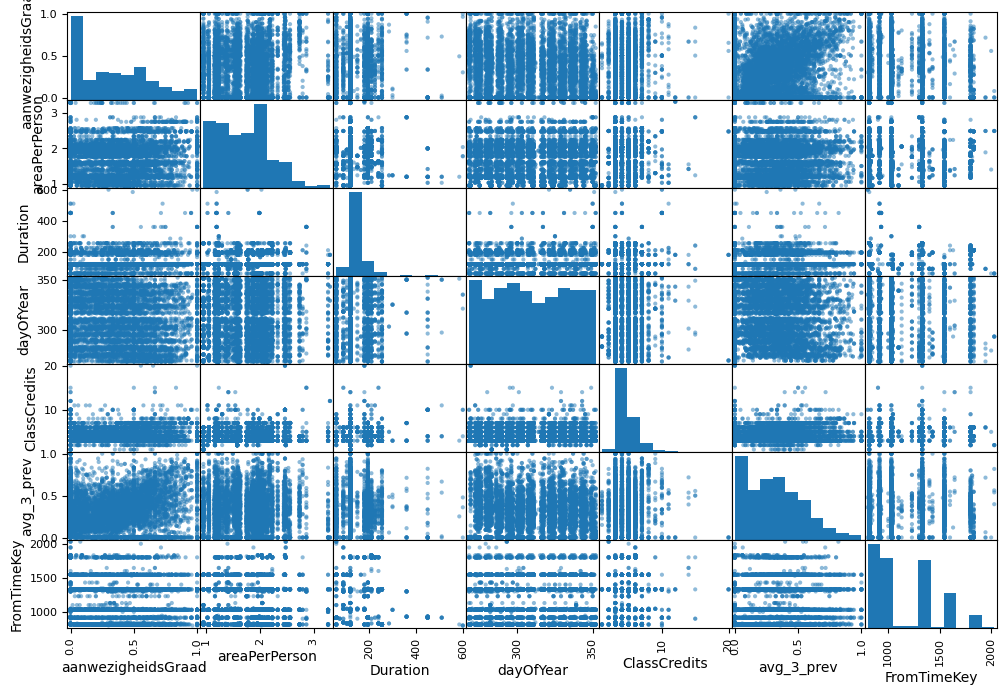

In [10]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[["aanwezigheidsGraad", "areaPerPerson", "Duration", "dayOfYear", "ClassCredits", "avg_3_prev", 'FromTimeKey']], figsize=(12, 8))

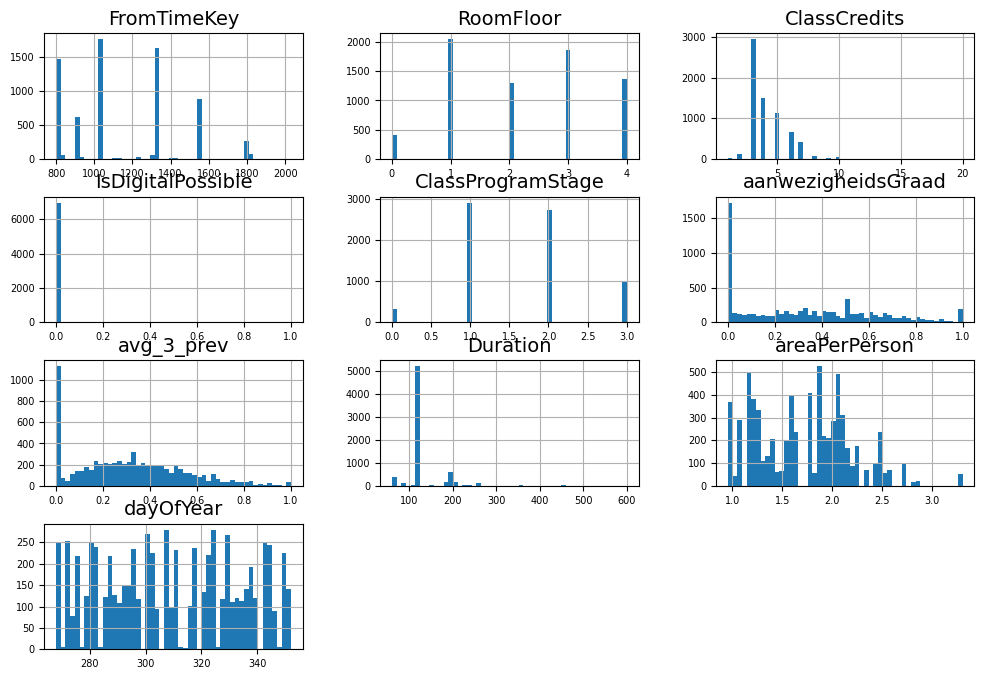

In [11]:
# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)

df.hist(bins=50, figsize=(12,8))
plt.show()

we merken dat er veel aanwezigheidsgraad 0.0 is, we zullen deze droppen om en kijken als de output van ons model hierdoor verbeterd

In [12]:
df = df[df["aanwezigheidsGraad"] != 0.0]
len(df)

5277

## Test set

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["aanwezigheidsGraad"])
y = df["aanwezigheidsGraad"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=False)

## Transformation Pipelines

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector, make_column_transformer

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehotencoder", OneHotEncoder(handle_unknown="ignore"))
])

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

num_features = X.select_dtypes(include=["int64, float64"]).columns
cat_features = X.select_dtypes(include=["str", "object"]).columns

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

## MODELS

we maken een dataframe aan om alle MAE's bij te houden

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_results = pd.DataFrame(columns=['Model', 'MAE', 'RMSE'])

def add_result(df, model_name, y_true, y_pred):
    # Bereken de statistieken
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Maak een nieuwe rij
    new_row = pd.DataFrame({'Model': [model_name], 'MAE': [mae], 'RMSE': [rmse]})
    
    # Voeg toe aan het bestaande dataframe
    return pd.concat([df, new_row], ignore_index=True)

### LinReg

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

linreg = make_pipeline(preprocessing, LinearRegression())
linreg.fit(X_train, y_train)

model_results = add_result(model_results, "Linear Regression", y_test, linreg.predict(X_test))

mae_linreg = mean_absolute_error(y_test, linreg.predict(X_test))
mae_linreg

0.19878863398150903

### Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor

rnd_forest = RandomForestRegressor(random_state=42, min_samples_split=5, n_estimators=500)

forest_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", rnd_forest)
])


forest_reg.fit(X_train, y_train)

model_results = add_result(model_results, "Random Forest", y_test, forest_reg.predict(X_test))

mae_rnd_forest = mean_absolute_error(y_test, forest_reg.predict(X_test))
mae_rnd_forest

0.17187668497460826

In [203]:
for score, name in zip(rnd_forest.feature_importances_, X_train.columns):
    print(round(score, 2), name)

0.06 FromTimeKey
0.04 SourceValue
0.06 Category
0.0 RoomFloor
0.04 ClassCredits
0.3 IsDigitalPossible
0.05 Season
0.14 ClassProgramStage
0.16 ProgramType
0.02 avg_3_prev
0.0 Duration
0.0 areaPerPerson
0.01 dayOfYear


### Linear SVR

In [130]:
from sklearn.svm import LinearSVR
from sklearn.model_selection import GridSearchCV

lin_svr_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("svr", LinearSVR(random_state=42))
])

params = {"svr__epsilon": [0.01, 0.1, 0.5, 2 ,2.5, 3, 5, 100]}

lin_svr = GridSearchCV(lin_svr_pipeline, params, scoring="neg_mean_absolute_error", cv=3)
lin_svr.fit(X_train, y_train)

model_results = add_result(model_results, "Linear SVR", y_test, lin_svr.predict(X_test))

lin_svr.best_score_

/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/arnz3/Ho

np.float64(-0.17847419410541066)

### Non-Linear SVR

In [131]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

params = {
    "svr__epsilon": [0.5, 2, 5, 100],
    "svr__kernel": ["rbf", "poly", "sigmoid", "linear"],
    "svr__degree": [1, 2, 3]
}

svr_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("svr", SVR(C=100, gamma="scale"))
])

svr = GridSearchCV(
    svr_pipeline,
    params,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3)
)

svr.fit(X_train,  y_train)

svr.best_score_

np.float64(-0.2141813413272964)

### Decision Tree

In [132]:
from sklearn.tree import DecisionTreeRegressor

params = {
    "dtree__max_depth": range(1, 10),
    "dtree__criterion": ["absolute_error", "poisson"],
    "dtree__min_samples_split": [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3 ,0.4]
}

dtree_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("dtree", DecisionTreeRegressor(random_state=42))
])

dtree = GridSearchCV(
    dtree_pipeline,
    params,
    scoring="neg_mean_absolute_error",
    cv=3
)

dtree.fit(X_train, y_train)

model_results = add_result(model_results, "Decision Tree", y_test, dtree.predict(X_test))

dtree.best_score_

np.float64(-0.17504414710136204)

In [133]:
dtree.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('dtree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [134]:
mae_dtree = mean_absolute_error(y_test, dtree.best_estimator_.predict(X_test))
mae_dtree

0.19095815502334743

### Stochastic Gradient Descent

In [135]:
from sklearn.linear_model import SGDRegressor

sgd = Pipeline([
    ("preprocessing", preprocessing),
    ("sgd", SGDRegressor(random_state=42, n_iter_no_change=100, max_iter=100, tol=1e-5, penalty=None, eta0=0.01))
])

sgd.fit(X_train, y_train)

model_results = add_result(model_results, "SGD Regressor", y_test, sgd.predict(X_test))

mae_sgd = mean_absolute_error(y_test, sgd.predict(X_test))
mae_sgd

/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.19849617398791988

### Polynomial Regression

In [57]:
from sklearn.preprocessing import PolynomialFeatures


poly_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("poly_features", PolynomialFeatures(include_bias=False, degree=3)),
    ("lin_reg", LinearRegression())
])


poly_reg.fit(X_train,  y_train)

mea_poly_reg = mean_absolute_error(y_test, poly_reg.predict(X_test))
mea_poly_reg

0.529651862489426

### Ridge Regression

In [136]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

ridge_reg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("poly_features", PolynomialFeatures(degree=3, include_bias=False)),
    ("ridge", Ridge(random_state=42))
])

params = {
    "ridge__alpha": [0.5, 1],
    "ridge__solver": ["cholesky", "sag"]
}

ridge_reg = GridSearchCV(
    ridge_reg_pipeline,
    params,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3)
)

ridge_reg.fit(X_train, y_train)

mea_ridge_reg = mean_absolute_error(y_test, ridge_reg.best_estimator_.predict(X_test))
mea_ridge_reg

/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

0.18292500306336165

### Lasso Regression

In [115]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

params = {"lasso_reg__alpha" : [0.01, 0.05, 0.1, 0.2, 0.5]}

lasso_reg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("lasso_reg", Lasso()),
])

lasso_reg = GridSearchCV(
    lasso_reg_pipeline,
    params,
    scoring="neg_mean_absolute_error",
    cv=3
)

lasso_reg.fit(X_train, y_train)

model_results = add_result(model_results, "Lasso Regression", y_test, lasso_reg.predict(X_test))

mae_lasso_reg = mean_absolute_error(y_test, lasso_reg.best_estimator_.predict(X_test))
mae_lasso_reg

0.2097622502148285

### Bagging Regressor

In [30]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bag_reg = BaggingRegressor(
    DecisionTreeRegressor(), n_estimators=1000,
    max_samples=500, bootstrap=False, n_jobs=-1, random_state=42
)

bag_reg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("bag_reg", bag_reg)
])

bag_reg_pipeline.fit(X_train, y_train)

model_results = add_result(model_results, "Bagging Regressor", y_test, bag_reg_pipeline.predict(X_test))

mae_bag_reg = mean_absolute_error(y_test, bag_reg_pipeline.predict(X_test))
mae_bag_reg


0.17747974426424556

### Ada Boosting

In [17]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=20), n_estimators=500,
    learning_rate=0.5, random_state=42
)

ada_reg_pipeline= Pipeline([
    ("preprocessing", preprocessing),
    ("adaboost", ada_reg)
])

ada_reg_pipeline.fit(X_train, y_train)

model_results = add_result(model_results, "AdaBoost Regressor", y_test, ada_reg_pipeline.predict(X_test))

mae_ada_reg = mean_absolute_error(y_test, ada_reg_pipeline.predict(X_test))
mae_ada_reg

0.17057327777589945

In [165]:
for score, name in zip(ada_reg.feature_importances_, X_train.columns):
    print(round(score, 2), name)

0.09 FromTimeKey
0.05 SourceValue
0.07 Category
0.0 RoomFloor
0.06 ClassCredits
0.22 IsDigitalPossible
0.04 Season
0.15 ClassProgramStage
0.19 ProgramType
0.02 avg_3_prev
0.0 Duration
0.0 areaPerPerson
0.01 dayOfYear


### Gradient boosting

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

grad_reg = GradientBoostingRegressor(max_depth=2, learning_rate=0.5, n_estimators=1000, n_iter_no_change=10, random_state=42)

grad_boost = Pipeline([
    ("preprocessing", preprocessing),
    ("grad_boost", grad_reg)
])

grad_boost.fit(X_train, y_train)

model_results = add_result(model_results, "Gradient Boosting Regressor", y_test, grad_boost.predict(X_test))

mae_grad_boost = mean_absolute_error(y_test, grad_boost.predict(X_test))
mae_grad_boost

0.18095119162923962

### Histogram-based Gradient boosting

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_grad_boost = Pipeline([
    ("preprocessing", preprocessing),
    ("hist_grad_boost", HistGradientBoostingRegressor(learning_rate=0.1, random_state=42))
]) 

hist_grad_boost.fit(X_train, y_train)

model_results = add_result(model_results, "Hist Gradient Boosting Regressor", y_test, hist_grad_boost.predict(X_test))  

mae_hist_grad_boost = mean_absolute_error(y_test, hist_grad_boost.predict(X_test))
mae_hist_grad_boost

0.1717500396325206

### XGBoost

In [22]:
from xgboost import XGBRegressor

xgb_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("xgb_reg", XGBRegressor(random_state=42))
])

xgb_reg.fit(X_train, y_train)

model_results = add_result(model_results, "XGBoost Regressor", y_test, xgb_reg.predict(X_test))

mae_xgb_reg = mean_absolute_error(y_test, xgb_reg.predict(X_test))
mae_xgb_reg

0.16950525754056633

### LightGBM

In [23]:
from lightgbm import LGBMRegressor

lgbm_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("lgbm_reg", LGBMRegressor(random_state=42))
])

lgbm_reg.fit(X_train, y_train)

model_results = add_result(model_results, "LightGBM Regressor", y_test, lgbm_reg.predict(X_test))

mae_lgbm_reg = mean_absolute_error(y_test, lgbm_reg.predict(X_test))
mae_lgbm_reg

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496
[LightGBM] [Info] Number of data points in the train set: 3957, number of used features: 26
[LightGBM] [Info] Start training from score 0.420259


/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.1703692206335696

### CatBoost

In [24]:
from catboost import CatBoostRegressor

catboost_reg = Pipeline([
    ("preprocessing", preprocessing),   
    ("catboost_reg", CatBoostRegressor(random_state=42, verbose=0))
])

catboost_reg.fit(X_train, y_train)

model_results = add_result(model_results, "CatBoost Regressor", y_test, catboost_reg.predict(X_test))

mae_catboost_reg = mean_absolute_error(y_test, catboost_reg.predict(X_test))
mae_catboost_reg

0.1665544429242956

### Voting Regressor

In [ ]:
from sklearn.ensemble import VotingRegressor
from catboost import CatBoostRegressor  
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

voting_reg = VotingRegressor(
    estimators=[
        ("light_gbm", LGBMRegressor(random_state=42)),
        ("cat_boost", CatBoostRegressor(random_state=42, verbose=0)),
        ("xgboost", XGBRegressor(random_state=42))
    ]
)

voting_reg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("voting_reg", voting_reg)
])


voting_reg_pipeline.fit(X_train, y_train)

model_results = add_result(model_results, "Voting Regressor", y_test, voting_reg_pipeline.predict(X_test))

mae_voting_reg = mean_absolute_error(y_test, voting_reg_pipeline.predict(X_test))
mae_voting_reg

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496
[LightGBM] [Info] Number of data points in the train set: 3957, number of used features: 26
[LightGBM] [Info] Start training from score 0.420259


/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/arnz3/Hogent/2/ML/project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.16557928295244756

### Stacking Regressor

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

stacking_reg = StackingRegressor(
    estimators=[
        ("ada_boost", ada_reg),
        ("cat_boost", CatBoostRegressor(random_state=42, verbose=0)),
        ("xgboost", XGBRegressor(random_state=42))
    ],
    final_estimator=RandomForestRegressor(random_state=43),
    cv=5
)

stacking_reg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("stacking_reg", stacking_reg)
])

stacking_reg_pipeline.fit(X_train, y_train)

model_results = add_result(model_results, "Stacking Regressor", y_test, stacking_reg_pipeline.predict(X_test))

mae_stacking_reg = mean_absolute_error(y_test, stacking_reg_pipeline.predict(X_test))
mae_stacking_reg

0.18106359390556834

### PCA
pca toepassen op adaboost


In [216]:
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostRegressor

pca = PCA(n_components=0.95, random_state=42)

ada_reg_pca = Pipeline([
    ("preprocessing", preprocessing),
    ("pca", pca),
    ("adaboost", ada_reg)
])

ada_reg_pca.fit(X_train, y_train)

model_results = add_result(model_results, "PCA", y_test, ada_reg_pca.predict(X_test))


mae_pca_ada = mean_absolute_error(y_test, ada_reg_pca.predict(X_test))
mae_pca_ada


0.1751809249438386

### Belangrijke features identificeren

We hebben duidelijk 3 modellen die het beter doen dan anderen. Deze modellen proberen we te maximaliseren, dit door onbelangrijke features te droppen om noise te verminderen.

In [166]:
# haal de feature importances van de 3 modellen en neem het gemiddelde ervan op deze manier kunnen we bepalen welke features het belangrijkst zijn voor de voorspelling van de aanwezigheidsgraad.

feature_importances = (ada_reg.feature_importances_ + rnd_forest.feature_importances_ + grad_reg.feature_importances_) / 3

for score, name in zip(ada_reg.feature_importances_, X_train.columns):
    print(round(score, 2), name)


0.09 FromTimeKey
0.05 SourceValue
0.07 Category
0.0 RoomFloor
0.06 ClassCredits
0.22 IsDigitalPossible
0.04 Season
0.15 ClassProgramStage
0.19 ProgramType
0.02 avg_3_prev
0.0 Duration
0.0 areaPerPerson
0.01 dayOfYear


### Anomalien verwijderen uit dataset

We gebruiken Gaussian mixtures om Anomalien te detecteren en deze uit de dataset te halen, op deze manier traint ons model niet op onrealistische data. Dit kan door dat het een opendeurdag is of doordat een accespoint toevallig traffic op de gang ook meetelt.

We passen dit enkel toe op de belangrijkste features

In [167]:
from sklearn.mixture import GaussianMixture

gm_train = X_train[["avg_3_prev", "areaPerPerson", "dayOfYear", "ClassCredits"]].copy()
gm_train["aanwezigheidsGraad"] = y_train


gm = GaussianMixture(n_components=5, n_init=10,random_state=42)

gm.fit(gm_train)

scores = gm.score_samples(gm_train)

density_threshold = np.percentile(scores, 2)
train_cleaned = gm_train[scores >= density_threshold]

X_train_cleaned = train_cleaned.drop(columns=["aanwezigheidsGraad"])
y_train_cleaned = train_cleaned["aanwezigheidsGraad"]

print(len(gm_train), len(train_cleaned))

3957 3878


We proberen nu Adaboost nog eens om te zien als de performance beter is.

In [123]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=20), n_estimators=500,
    learning_rate=0.5, random_state=42
)

ada_reg_pipeline= Pipeline([
    ("preprocessing", preprocessing),
    ("adaboost", ada_reg)
])

ada_reg_pipeline.fit(X_train_cleaned, y_train_cleaned)

mae_ada_reg = mean_absolute_error(y_test, ada_reg_pipeline.predict(X_test))
mae_ada_reg

0.18601442541994595

Als we PCA toepassen dan zien we dat helaas de performance niet beter wordt.

## Gridsearch op beste

In [ ]:
model_results.drop_duplicates(subset=['Model'], keep='last', inplace=True)
best_models = model_results.sort_values(by='MAE', ascending=True)
print(best_models)
model_results

                              Model       MAE      RMSE
5                CatBoost Regressor  0.166554   0.21583
3                 XGBoost Regressor  0.169505  0.219436
4                LightGBM Regressor  0.170369  0.219045
7                AdaBoost Regressor  0.170573  0.219081
2  Hist Gradient Boosting Regressor   0.17175  0.220695
1                     Random Forest  0.171877  0.219813
8                 Bagging Regressor   0.17748  0.225579
6       Gradient Boosting Regressor  0.180951  0.232765
0                 Linear Regression  0.198789  0.247625


,Model,MAE,RMSE
0,Linear Regression,0.198789,0.247625
1,Random Forest,0.171877,0.219813
2,Hist Gradient Boosting Regressor,0.17175,0.220695
3,XGBoost Regressor,0.169505,0.219436
4,LightGBM Regressor,0.170369,0.219045
5,CatBoost Regressor,0.166554,0.21583
6,Gradient Boosting Regressor,0.180951,0.232765
7,AdaBoost Regressor,0.170573,0.219081
8,Bagging Regressor,0.17748,0.225579


We passen nu Gridsearch toe op enkele van onze beste modellen, dit om de hyperparameters te optimaliseren

### GridSearch Ada Boosting

In [18]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

params = {
    "adaboost__learning_rate": [0.01, 0.1, 0.5, 1],
    "adaboost__n_estimators": [100, 500, 1000]
}

ada_grid_search = GridSearchCV(
    ada_reg_pipeline,
    params,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3)
)

ada_grid_search.fit(X_train, y_train)

mae = mean_absolute_error(y_test, ada_grid_search.predict(X_test))
print("Best Hyperparameters:", ada_grid_search.best_params_)
print("Best score:", ada_grid_search.best_score_)
print("MAE:", mae)


Best Hyperparameters: {'adaboost__learning_rate': 0.1, 'adaboost__n_estimators': 500}
Best score: -0.1621307751085604
MAE: 0.16703210311476357


### Gridsearch Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

params = {
    "random_forest__n_estimators": [100, 500, 1000],
    "random_forest__max_depth": [2, 3, 4, 5],
    "random_forest__max_features": [2, 4, 6, 8]
}

random_forest_grid_search = GridSearchCV(
    forest_reg,
    params,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3)
)

random_forest_grid_search.fit(X_train, y_train)

mae = mean_absolute_error(y_test, random_forest_grid_search.predict(X_test))
print("Best Hyperparameters:", random_forest_grid_search.best_params_)
print("Best score:", random_forest_grid_search.best_score_)
print("MAE:", mae)

Best Hyperparameters: {'random_forest__max_depth': 5, 'random_forest__max_features': 8, 'random_forest__min_samples_split': 0.01, 'random_forest__n_estimators': 500}
Best score: -0.17795884553608746
MAE: 0.19431113793515575


### GridSearch Catboost

In [36]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from catboost import CatBoostRegressor

params = {
    "catboost__learning_rate": [0.01, 0.1, 0.5, 1],
    "catboost__n_estimators": [100, 500, 1000],
    "catboost__depth": [2, 5, 10]
}

catboost_reg = Pipeline([
    ("preprocessing", preprocessing),   
    ("catboost", CatBoostRegressor(random_state=42, verbose=0))
])

catboost_grid_search = GridSearchCV(
    catboost_reg,
    params,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3)
)

catboost_grid_search.fit(X_train, y_train)

mae = mean_absolute_error(y_test, catboost_grid_search.predict(X_test))
print("Best Hyperparameters:", catboost_grid_search.best_params_)
print("Best score:", catboost_grid_search.best_score_)
print("MAE:", mae)

Best Hyperparameters: {'catboost__depth': 10, 'catboost__learning_rate': 0.01, 'catboost__n_estimators': 1000}
Best score: -0.16253402981178489
MAE: 0.1686977324392883


### Gridsearch XGBoost

In [38]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV

params = {
    "xgb_reg__learning_rate": [0.01, 0.1, 0.5, 1],
    "xgb_reg__n_estimators": [100, 500, 1000],
    "xgb_reg__max_depth": [2, 5, 10]
}

xgb_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("xgb_reg", XGBRegressor(random_state=42))
])

xgb_randomized_search = RandomizedSearchCV(
    xgb_reg,
    params,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3),
    n_iter=10
)

xgb_randomized_search.fit(X_train, y_train)

mae = mean_absolute_error(y_test, xgb_randomized_search.predict(X_test))
print("Best Hyperparameters:", xgb_randomized_search.best_params_)
print("Best score:", xgb_randomized_search.best_score_)
print("MAE:", mae)

Best Hyperparameters: {'xgb_reg__n_estimators': 1000, 'xgb_reg__max_depth': 5, 'xgb_reg__learning_rate': 0.01}
Best score: -0.16508371130514823
MAE: 0.17435827587070674


## Learning Curves

### Adaboost

In [34]:
from sklearn.model_selection import learning_curve

best_ada = AdaBoostRegressor(learning_rate=0.1, n_estimators=500, random_state=42)

ada = Pipeline([
    ("preprocessing", preprocessing),
    ("adaboost", best_ada)
])

train_sizes, train_scores, valid_scores = learning_curve(
    ada, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_mean_absolute_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)


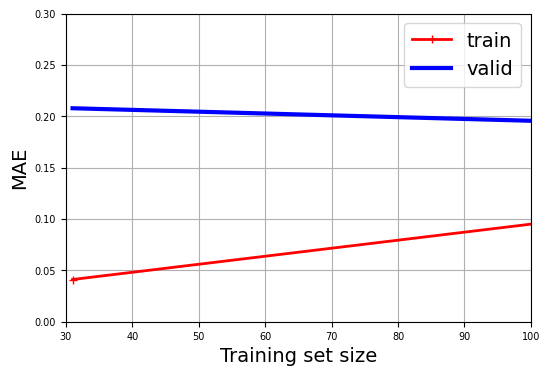

In [23]:
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("MAE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([30,100, 0, 0.3])
plt.show()

### Random Forrest

In [47]:
rnd_for = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(max_depth=5, max_features=8, min_samples_split=0.01, n_estimators=500, random_state=42))
])

train_sizes, train_scores, valid_scores = learning_curve(
    rnd_for, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_mean_absolute_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

KeyboardInterrupt: 

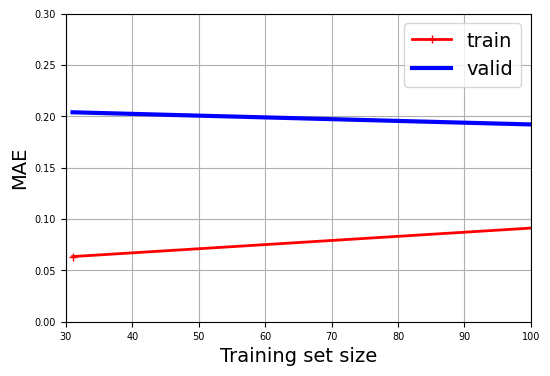

In [ ]:
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("MAE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([30,100, 0, 0.3])
plt.show()

### Bagging Regressor

In [ ]:
bagging_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("bagging", BaggingRegressor(n_estimators=500, max_samples=1000, bootstrap=True, n_jobs=-1, random_state=42))
])

train_sizes, train_scores, valid_scores = learning_curve(
    bagging_reg, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_mean_absolute_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

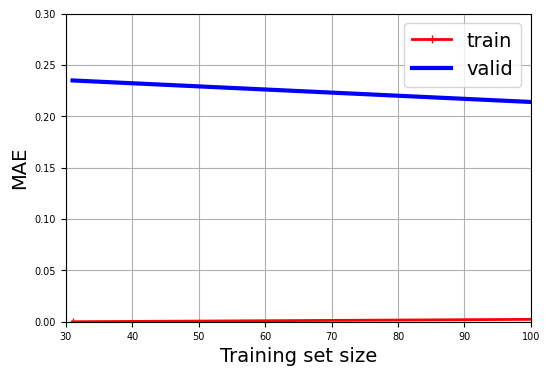

In [ ]:
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("MAE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([30,100, 0, 0.3])
plt.show()

### CatBoost

In [25]:
from catboost import CatBoostRegressor
catboost_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("catboost", CatBoostRegressor(random_state=42, verbose=0, depth=10, learning_rate=0.01, n_estimators=1000))
])

train_sizes, train_scores, valid_scores = learning_curve(
    catboost_reg, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_mean_absolute_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

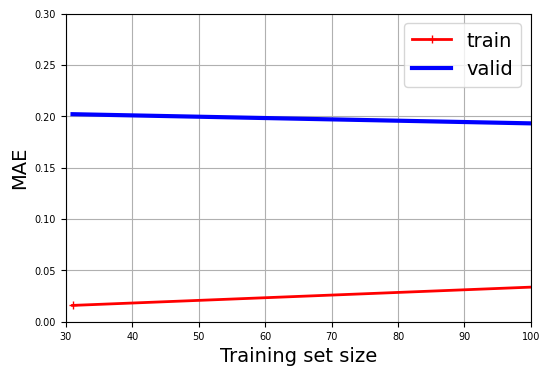

In [52]:
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("MAE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([30,100, 0, 0.3])
plt.show()

# Explainability

## shapley values

In [ ]:
X_train_encoded = preprocessing.fit_transform(X_train)
columns = preprocessing.get_feature_names_out()
X_train_encoded = pd.DataFrame(X_train_encoded, columns=columns)

X_train_encoded.columns = X_train_encoded.columns.str.replace("pipeline-1__", "").str.replace("pipeline-2__", "")
X_train_encoded


,FromTimeKey,RoomFloor,ClassCredits,IsDigitalPossible,ClassProgramStage,avg_3_prev,Duration,areaPerPerson,dayOfYear,SourceValue_Activerend hoorcollege,...,Category_leslokaal,Category_practicum,Season_Autumn,Season_Winter,ProgramType_BNB,ProgramType_GRAD,ProgramType_INT,ProgramType_MC,ProgramType_PBA,ProgramType_PGD
0,1.375505,1.486393,0.548867,0.0,-0.767343,0.068280,-0.261875,1.625386,0.341127,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.241388,-0.154465,-0.101003,0.0,0.514369,-1.471266,-0.261875,-0.970662,0.300739,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.103297,-0.974895,1.198737,0.0,-0.767343,-0.432968,-0.261875,-0.243720,-0.264689,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2.241388,-0.974895,-0.750874,0.0,-0.767343,-1.141363,-0.261875,-0.243720,0.502678,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2.241388,-0.974895,-0.750874,0.0,-0.767343,-1.471266,-0.261875,-0.243720,-0.062751,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3952,-0.373239,1.486393,-0.750874,0.0,0.514369,0.985592,-0.261875,1.758965,-1.193607,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3953,-0.373239,1.486393,-0.750874,0.0,1.796081,1.949946,-0.261875,-0.394292,0.785392,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3954,-0.373239,1.486393,-0.101003,0.0,1.796081,0.838052,-0.261875,-0.417189,-0.345465,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3955,-0.373239,1.486393,-0.750874,0.0,1.796081,2.096570,-0.261875,-0.394292,0.502678,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [41]:
best_ada.fit(X_train_encoded, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",500
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [43]:
import shap

explainer = shap.Explainer(best_ada.predict, X_train_encoded)
shap_values = explainer(X_train_encoded)

PermutationExplainer explainer: 3958it [04:52, 13.15it/s]                          


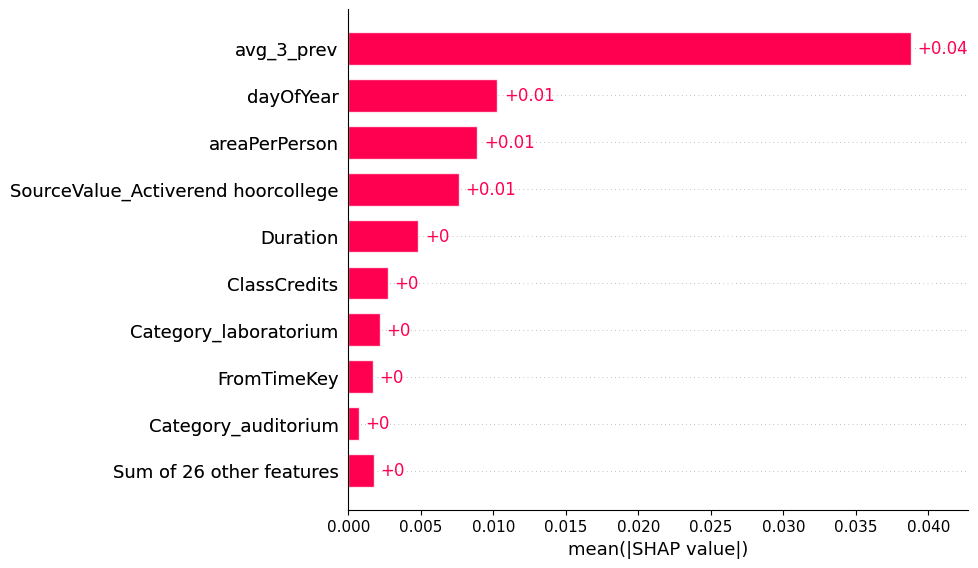

In [44]:
shap.plots.bar(shap_values)

# Tijds onafhankelijk